In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Import Data

In [70]:
df=pd.read_csv('heart.csv')

In [71]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [72]:
df.shape

(918, 12)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [74]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


# Handle missing values

In [75]:
df.isnull().sum()   

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

# Exploratory Data Analysis , Data Cleaning & Data Preprocessing

## Single Variable

### Age

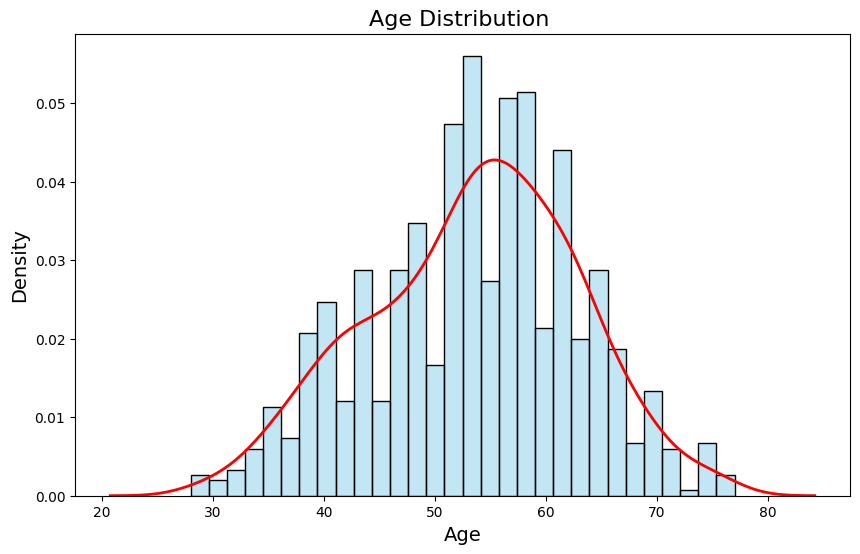

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64


In [76]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue', stat='density', alpha=0.5)
sns.kdeplot(df['Age'], color='red', linewidth=2) 
plt.title('Age Distribution ', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Density', fontsize=14)

# Show the plot
plt.show()
print(df.Age.describe())

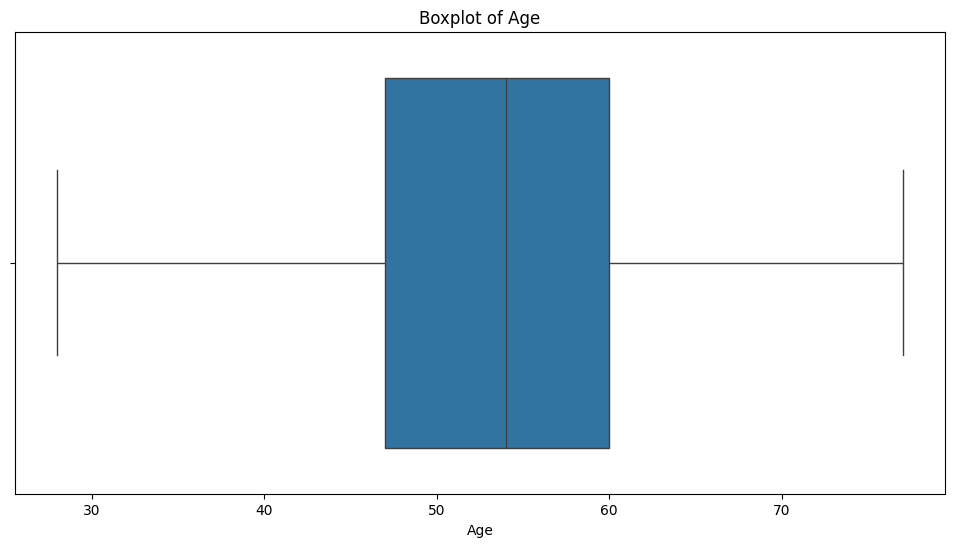

In [77]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Age', data=df)
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

- no noisy data or outliers found

### Sex

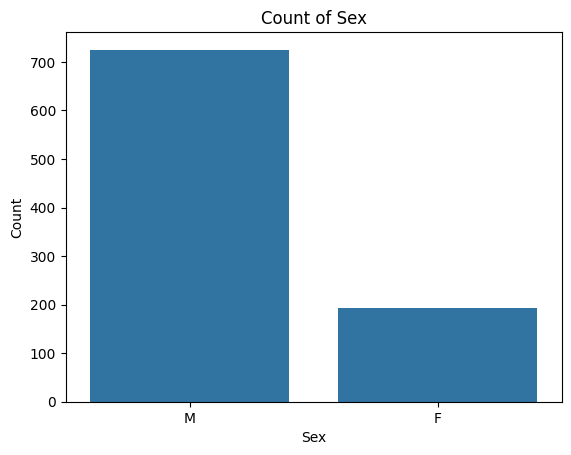

Sex
M    725
F    193
Name: count, dtype: int64

In [78]:
sns.countplot(x='Sex', data=df)
plt.title('Count of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

df['Sex'].value_counts()

### ChestPainType

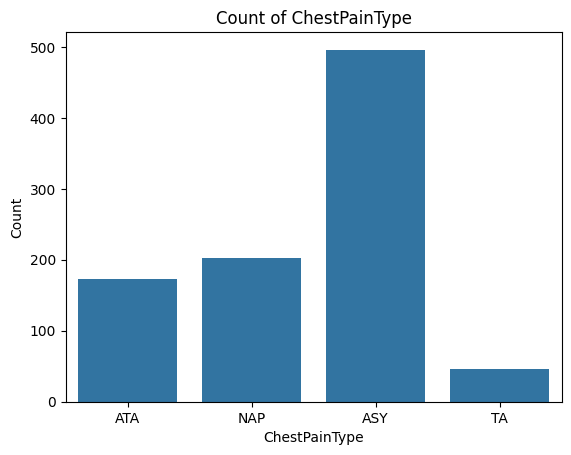

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [79]:
sns.countplot(x='ChestPainType', data=df)
plt.title('Count of ChestPainType')
plt.xlabel('ChestPainType')
plt.ylabel('Count')
plt.show()

df['ChestPainType'].value_counts()

In [80]:
df['ChestPainType'].value_counts()/df.shape[0] *100 # ChestPainType distribution percentage

ChestPainType
ASY    54.030501
NAP    22.113290
ATA    18.845316
TA      5.010893
Name: count, dtype: float64

- The data shows the distribution of chest pain types, with ASY being the most common (54.03%), followed by NAP (22.11%), ATA (18.85%), and TA (5.01%).

### RestingBP

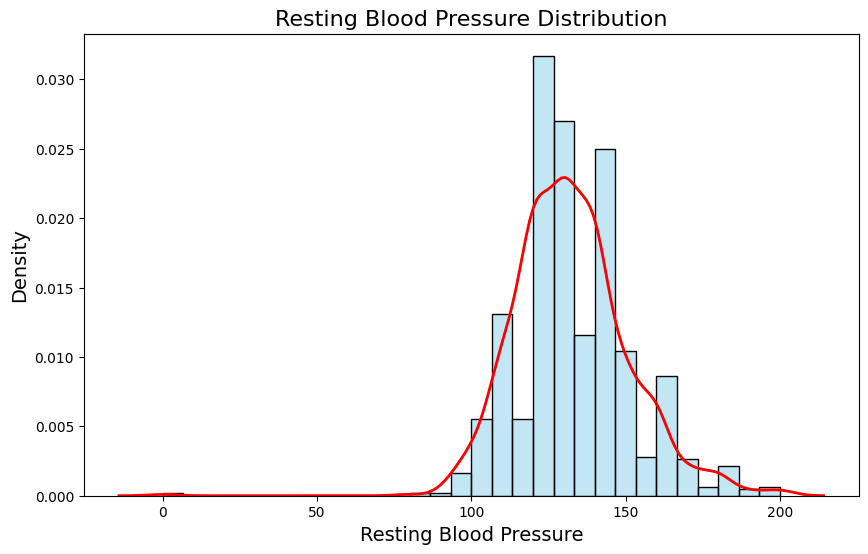

count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64


In [81]:
plt.figure(figsize=(10, 6))
sns.histplot(df['RestingBP'], bins=30, kde=True, color='skyblue', stat='density', alpha=0.5)
sns.kdeplot(df['RestingBP'], color='red', linewidth=2) 
plt.title('Resting Blood Pressure Distribution', fontsize=16)
plt.xlabel('Resting Blood Pressure', fontsize=14)
plt.ylabel('Density', fontsize=14)

# Show the plot
plt.show()
print(df.RestingBP.describe())

- bell-shaped distribution

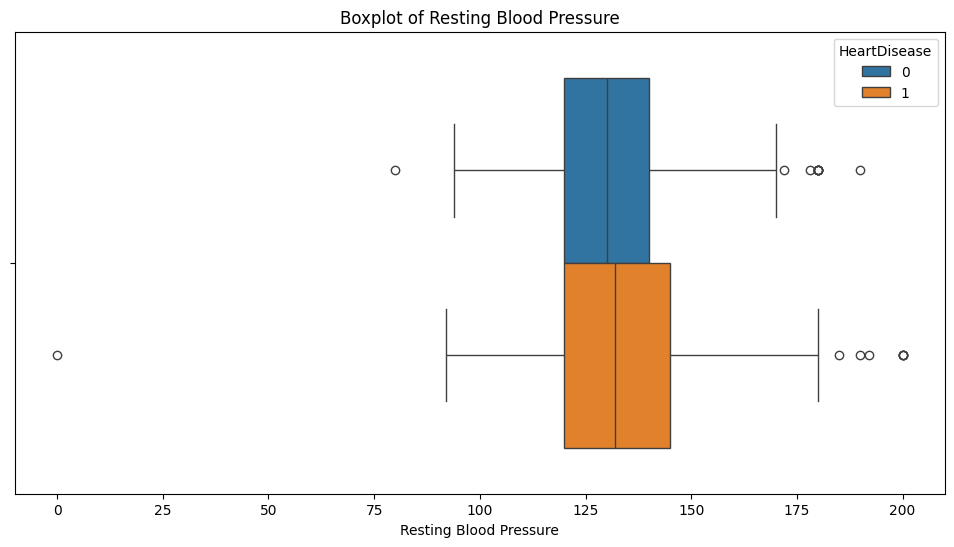

In [82]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='RestingBP', data=df,hue='HeartDisease')
plt.title('Boxplot of Resting Blood Pressure')
plt.xlabel('Resting Blood Pressure')
plt.show()

In [83]:
Q1 = df['RestingBP'].quantile(0.25)
Q3 = df['RestingBP'].quantile(0.75)
max = df['RestingBP'].max()
min = df['RestingBP'].min()
print(f"Q1: {Q1}, Q3: {Q3}, Max: {max}, Min: {min}")
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_normal = df[( (df['RestingBP'] < lower_bound) | (df['RestingBP'] > upper_bound) ) & (df['HeartDisease'] == 0)]
outliers_heartDisease = df[( (df['RestingBP'] < lower_bound) | (df['RestingBP'] > upper_bound) ) & (df['HeartDisease'] == 1)]
# Count the number of outliers
print(f'Number of outliers (normal): {outliers_normal.shape[0]}')
print(f'Number of outliers (heart disease): {outliers_heartDisease.shape[0]}')

Q1: 120.0, Q3: 140.0, Max: 200, Min: 0
Number of outliers (normal): 10
Number of outliers (heart disease): 18


- we have 28 outliers in total for this attribute

In [84]:
# Display the outliers
df[(df['RestingBP'] < lower_bound) | (df['RestingBP'] > upper_bound)].loc[:, ['RestingBP','HeartDisease']]

,RestingBP,HeartDisease
109,190,0
123,180,1
189,180,1
190,180,0
241,200,1
274,180,0
275,180,0
278,180,0
314,80,0
365,200,1


Analyze whether this would have an effect on out response variable - Heart Disease

##### Handle Noise

- 0 Resting BP must be an invalid data due to error in collection of data, we will remove this row
- In medical context, resting BP around 180 is treated as (severe hypertension), it is still valid data point , we will keep of them for analysis as 27 outliers is still moderate amount in 918 observations

In [85]:
df=df[df['RestingBP'] != 0]
df.shape

(917, 12)

### Cholesterol

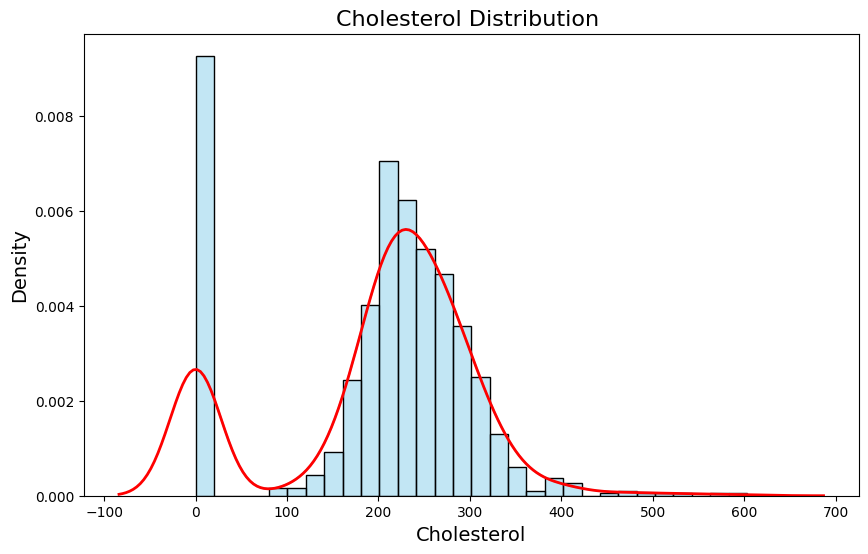

count    917.000000
mean     199.016358
std      109.246330
min        0.000000
25%      174.000000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64


In [86]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Cholesterol'], bins=30, kde=True, color='skyblue', stat='density', alpha=0.5)
sns.kdeplot(df['Cholesterol'], color='red', linewidth=2) 
plt.title('Cholesterol Distribution ', fontsize=16)
plt.xlabel('Cholesterol', fontsize=14)
plt.ylabel('Density', fontsize=14)

# Show the plot
plt.show()
print(df.Cholesterol.describe())

- bimodal distribution identified, with a significant amount of data  cholestrol = 0

##### Handle Noise

In [87]:
df[df['Cholesterol'] == 0].count() 

Age               171
Sex               171
ChestPainType     171
RestingBP         171
Cholesterol       171
FastingBS         171
RestingECG        171
MaxHR             171
ExerciseAngina    171
Oldpeak           171
ST_Slope          171
HeartDisease      171
dtype: int64

- 171 cholestrol values are 0 

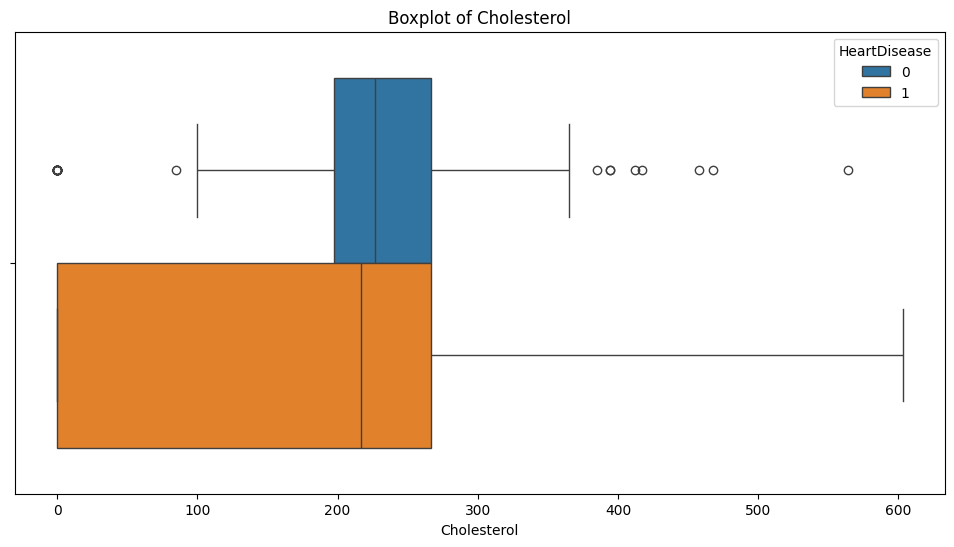

In [88]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cholesterol', data=df,hue='HeartDisease')
plt.title('Boxplot of Cholesterol')
plt.xlabel('Cholesterol')
plt.show()

- Since 0 cholestrol level is impossible in medical context, these zero values are interpreted as miscollect data or values that are imputed manually
- We would remove all these 171 values

In [89]:
df=df[df['Cholesterol']!=0]

In [90]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


- Re-plot Histogram & box plot again

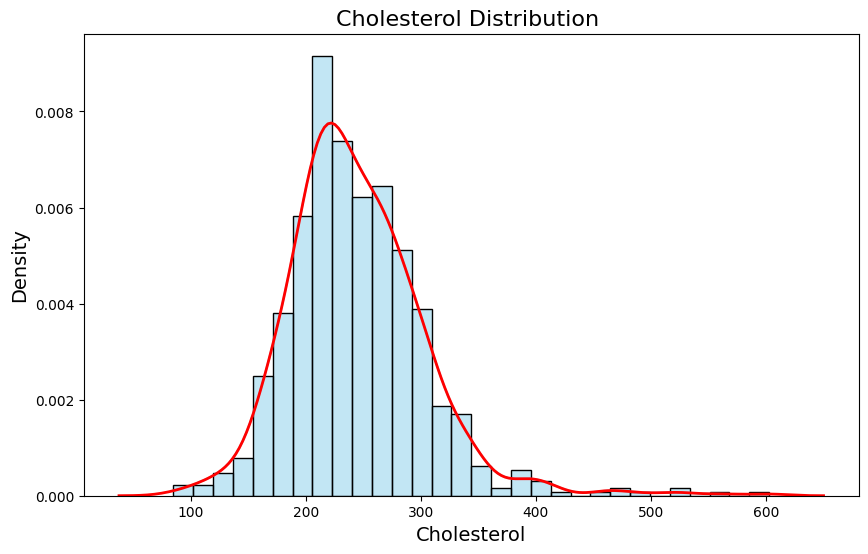

count    746.000000
mean     244.635389
std       59.153524
min       85.000000
25%      207.250000
50%      237.000000
75%      275.000000
max      603.000000
Name: Cholesterol, dtype: float64


In [91]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Cholesterol'], bins=30, kde=True, color='skyblue', stat='density', alpha=0.5)
sns.kdeplot(df['Cholesterol'], color='red', linewidth=2) 
plt.title('Cholesterol Distribution ', fontsize=16)
plt.xlabel('Cholesterol', fontsize=14)
plt.ylabel('Density', fontsize=14)

# Show the plot
plt.show()
print(df.Cholesterol.describe())

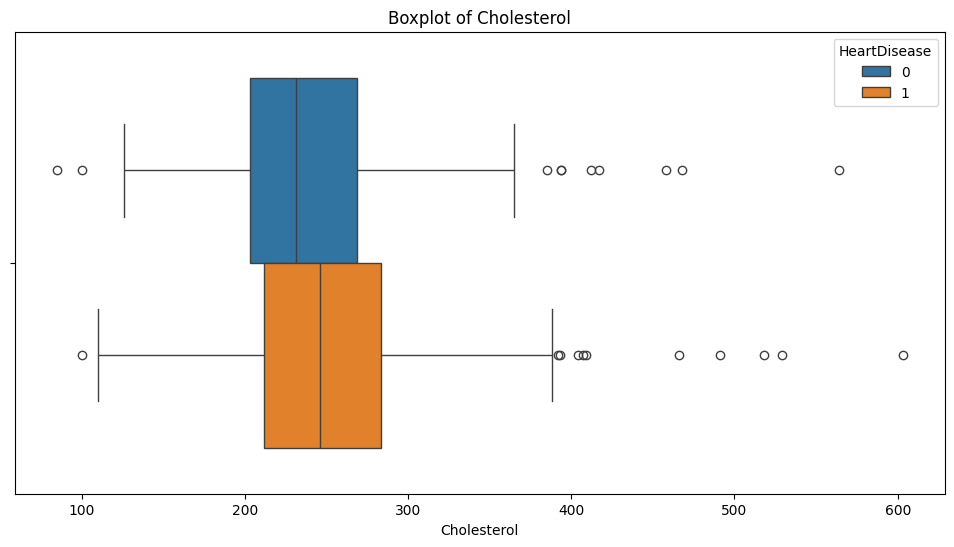

In [92]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cholesterol', data=df,hue='HeartDisease')
plt.title('Boxplot of Cholesterol')
plt.xlabel('Cholesterol')
plt.show()

In [93]:
Q1 = df['Cholesterol'].quantile(0.25)
Q3 = df['Cholesterol'].quantile(0.75)
max = df['Cholesterol'].max()
min = df['Cholesterol'].min()
print(f"Q1: {Q1}, Q3: {Q3}, Max: {max}, Min: {min}")
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_normal = df[( (df['Cholesterol'] < lower_bound) | (df['Cholesterol'] > upper_bound) ) & (df['HeartDisease'] == 0)]
outliers_heartDisease = df[( (df['Cholesterol'] < lower_bound) | (df['Cholesterol'] > upper_bound) ) & (df['HeartDisease'] == 1)]
# Count the number of outliers
print(f'Number of outliers (normal): {outliers_normal.shape[0]}')
print(f'Number of outliers (heart disease): {outliers_heartDisease.shape[0]}')

Q1: 207.25, Q3: 275.0, Max: 603, Min: 85
Number of outliers (normal): 10
Number of outliers (heart disease): 13


- both class have similar number of outliers and 23 outliers in 746 observations (around 3 %) is moderate. We would keep the remaining in our analysis

### FastingBS

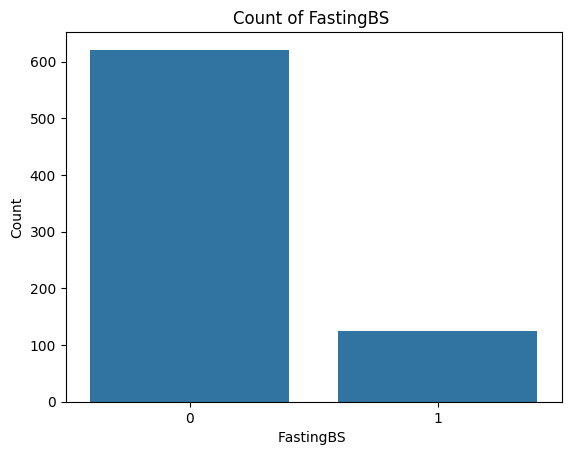

FastingBS
0    621
1    125
Name: count, dtype: int64

In [94]:
sns.countplot(x='FastingBS', data=df)
plt.title('Count of FastingBS ')
plt.xlabel('FastingBS ')
plt.ylabel('Count')
plt.show()

df['FastingBS'].value_counts()

### RestingECG

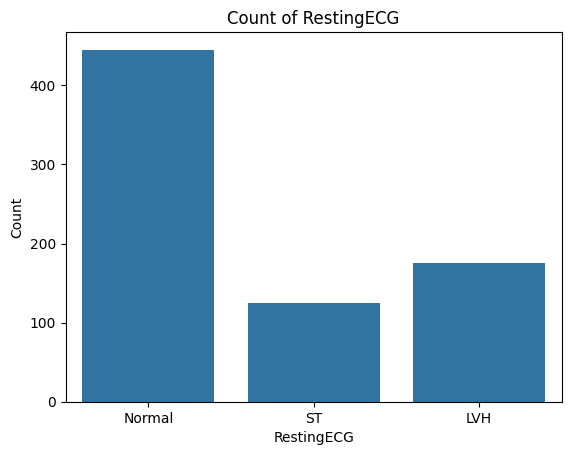

RestingECG
Normal    445
LVH       176
ST        125
Name: count, dtype: int64

In [95]:
sns.countplot(x='RestingECG', data=df)
plt.title('Count of RestingECG')
plt.xlabel('RestingECG')
plt.ylabel('Count')
plt.show()

df['RestingECG'].value_counts()

### MaxHR

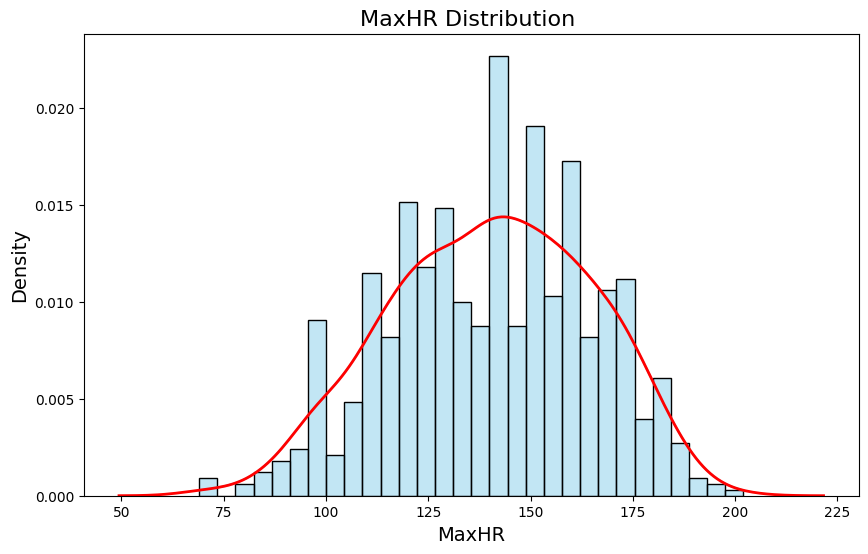

count    746.000000
mean     140.226542
std       24.524107
min       69.000000
25%      122.000000
50%      140.000000
75%      160.000000
max      202.000000
Name: MaxHR, dtype: float64


In [96]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MaxHR'], bins=30, kde=True, color='skyblue', stat='density', alpha=0.5)
sns.kdeplot(df['MaxHR'], color='red', linewidth=2) 
plt.title('MaxHR Distribution ', fontsize=16)
plt.xlabel('MaxHR', fontsize=14)
plt.ylabel('Density', fontsize=14)

# Show the plot
plt.show()
print(df.MaxHR.describe())

- bell-shaped distribution

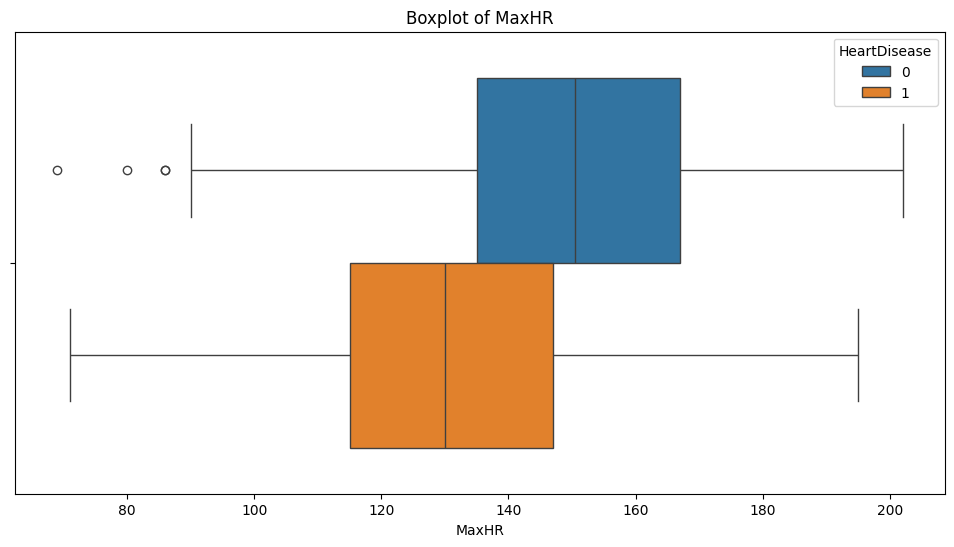

In [97]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='MaxHR', data=df,hue='HeartDisease')
plt.title('Boxplot of MaxHR')
plt.xlabel('MaxHR')
plt.show()

- just few number of outliers and all fall in reasonable range, we will keep all of them

### ExerciseAngina:

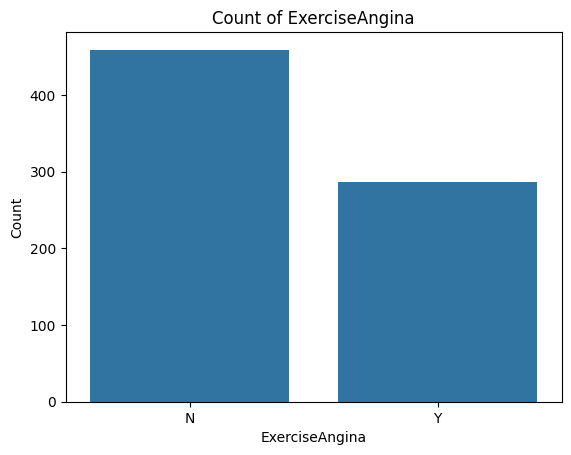

ExerciseAngina
N    459
Y    287
Name: count, dtype: int64

In [98]:
sns.countplot(x='ExerciseAngina', data=df)
plt.title('Count of ExerciseAngina')
plt.xlabel('ExerciseAngina')
plt.ylabel('Count')
plt.show()

df['ExerciseAngina'].value_counts()

### Oldpeak

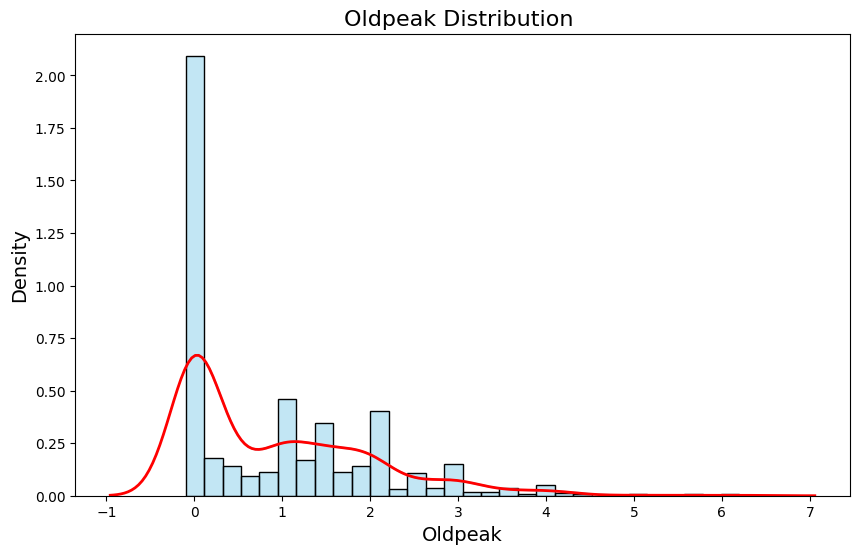

count    746.000000
mean       0.901609
std        1.072861
min       -0.100000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64


In [99]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Oldpeak'], bins=30, kde=True, color='skyblue', stat='density', alpha=0.5)
sns.kdeplot(df['Oldpeak'], color='red', linewidth=2) 
plt.title('Oldpeak Distribution ', fontsize=16)
plt.xlabel('Oldpeak', fontsize=14)
plt.ylabel('Density', fontsize=14)

# Show the plot
plt.show()
print(df.Oldpeak.describe())

- skewed distribution identified; standardization might be needed

### ST_Slope

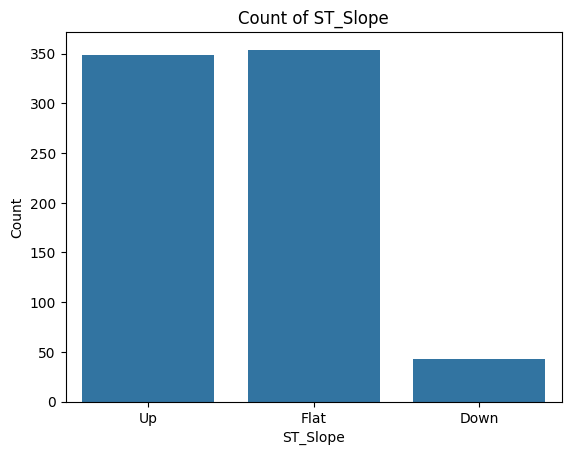

ST_Slope
Flat    354
Up      349
Down     43
Name: count, dtype: int64

In [100]:
sns.countplot(x='ST_Slope', data=df)
plt.title('Count of ST_Slope')
plt.xlabel('ST_Slope')
plt.ylabel('Count')
plt.show()

df['ST_Slope'].value_counts()

### Y : HeartDisease

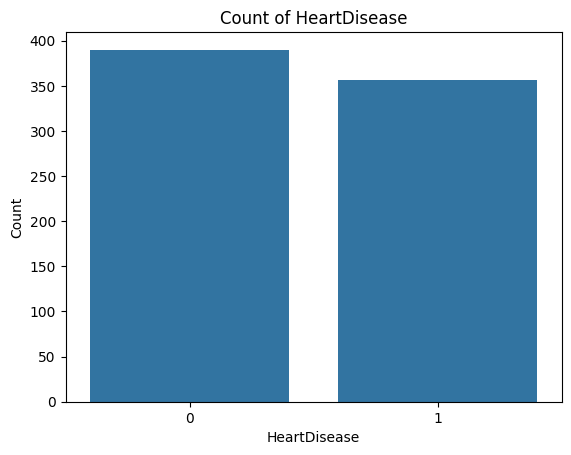

HeartDisease
0    390
1    356
Name: count, dtype: int64

In [101]:
sns.countplot(x='HeartDisease', data=df)
plt.title('Count of HeartDisease')
plt.xlabel('HeartDisease')
plt.ylabel('Count')
plt.show()

df['HeartDisease'].value_counts()

- classes of response are almost balanced

In [102]:
df.to_csv('heart-cleaned.csv', index=False)

## Correlation analysis

In [103]:
df.corr(numeric_only=True)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.259865,0.058758,0.241338,-0.382112,0.286006,0.298617
RestingBP,0.259865,1.000000,0.095939,0.173765,-0.125774,0.198575,0.173242
Cholesterol,0.058758,0.095939,1.000000,0.054012,-0.019856,0.058488,0.103866
FastingBS,0.241338,0.173765,0.054012,1.000000,-0.102710,0.055568,0.160594
MaxHR,-0.382112,-0.125774,-0.019856,-0.102710,1.000000,-0.259533,-0.377212
Oldpeak,0.286006,0.198575,0.058488,0.055568,-0.259533,1.000000,0.495696
HeartDisease,0.298617,0.173242,0.103866,0.160594,-0.377212,0.495696,1.000000


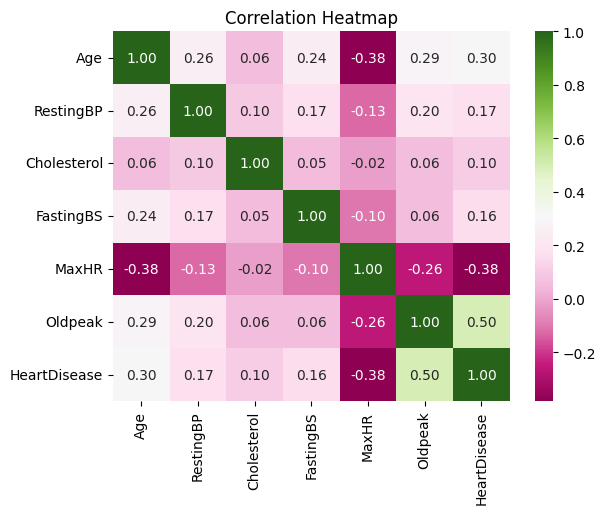

In [104]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='PiYG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()  

- most of the features are not having linear correlation
- (OldPeak vs Heart Dieseases) showing a correlation value 0.5, which indicates that OldPeak might be significant in contributing the response variable Y 
- The analysis of age versus maximum heart rate (MaxHR) and MaxHR versus heart diseases reveals a negative correlation of -0.38. This indicates that older individuals tend to have a lower MaxHR, while those with a lower MaxHR are more likely to have heart diseases.
- The analysis of age versus heart diseases shows a weak positive linear correlation of 0.3. This indicates that older individuals are more likely to have heart disease. Age could be another significant factor contributing to the occurrence of heart disease.

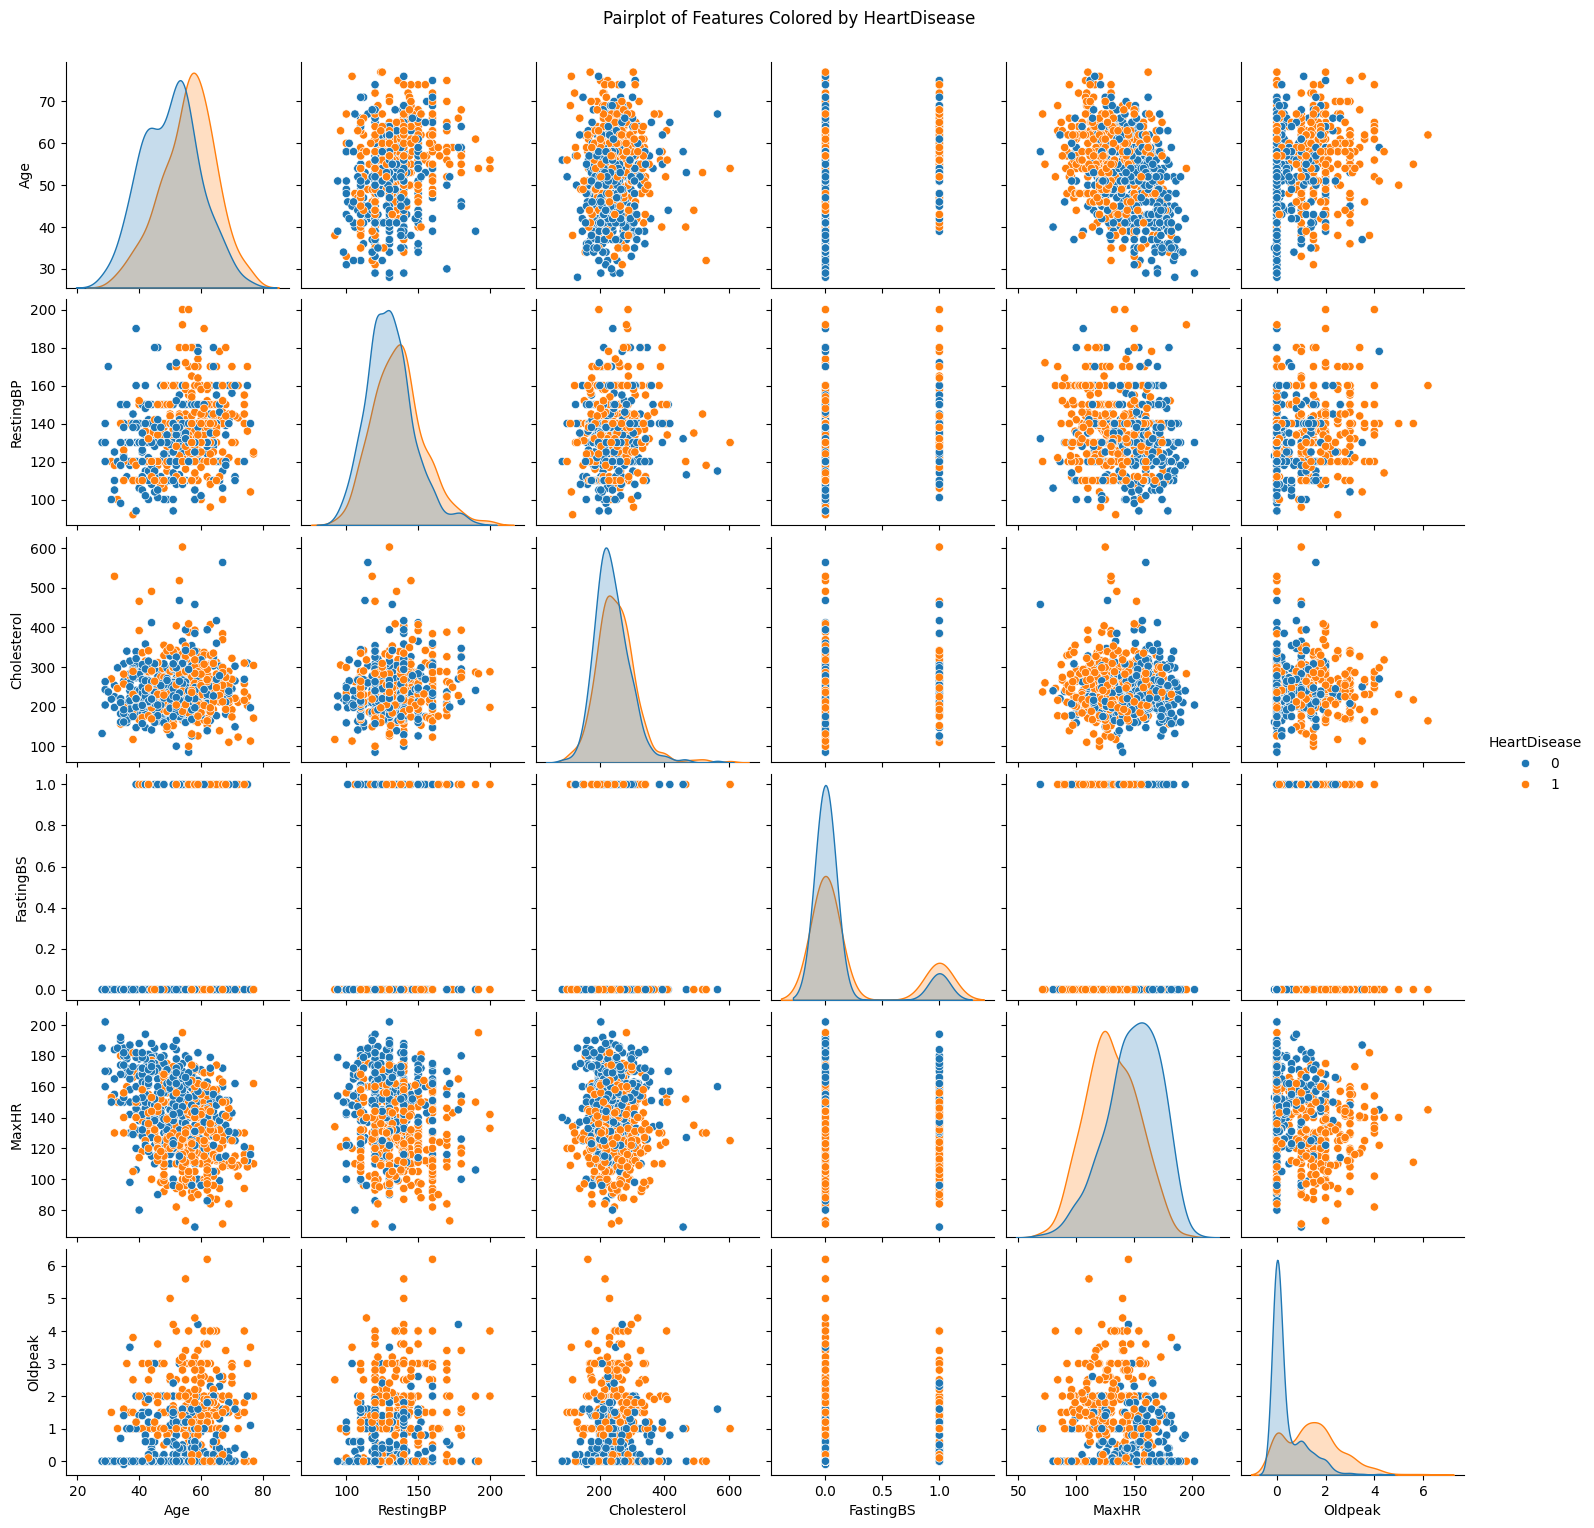

In [105]:
sns.pairplot(df, hue='HeartDisease')
plt.suptitle('Pairplot of Features Colored by HeartDisease', y=1.02)
plt.show()

# Experiment on Logistic Regression

In [106]:
from ISLP.models import (ModelSpec as MS,
                         summarize)
import statsmodels.api as sm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
y = df['HeartDisease']
X = df.drop(columns=['HeartDisease'])

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True).astype(int)
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [107]:
X_train

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
70,57,140,265,0,145,1,1,1,0,0,0,1,1,1,0
164,52,140,225,0,140,0,0,1,0,0,1,0,0,0,1
882,56,140,294,0,153,1,0,1,0,0,0,0,0,1,0
265,54,160,305,0,175,0,1,1,0,0,1,0,0,0,1
250,44,135,491,0,135,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,44,130,215,0,135,0,1,1,0,0,1,0,0,0,1
106,48,120,254,0,110,0,0,0,0,0,0,1,0,0,1
270,45,120,225,0,140,0,1,0,0,0,1,0,0,0,1
607,53,144,300,1,128,1,1,0,0,0,0,1,1,1,0


In [108]:
y_train

70     1
164    0
882    0
265    0
250    1
      ..
71     0
106    0
270    0
607    1
102    1
Name: HeartDisease, Length: 596, dtype: int64

In [109]:
design = MS(X_train.columns)
X_train_transformed = design.fit_transform(X_train)
y_train_transformed = y_train==1
X_test_transformed = design.transform(X_test)
y_test_transformed = y_test==1


In [110]:
X_train_transformed 

,intercept,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
70,1.0,57,140,265,0,145,1,1,1,0,0,0,1,1,1,0
164,1.0,52,140,225,0,140,0,0,1,0,0,1,0,0,0,1
882,1.0,56,140,294,0,153,1,0,1,0,0,0,0,0,1,0
265,1.0,54,160,305,0,175,0,1,1,0,0,1,0,0,0,1
250,1.0,44,135,491,0,135,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1.0,44,130,215,0,135,0,1,1,0,0,1,0,0,0,1
106,1.0,48,120,254,0,110,0,0,0,0,0,0,1,0,0,1
270,1.0,45,120,225,0,140,0,1,0,0,0,1,0,0,0,1
607,1.0,53,144,300,1,128,1,1,0,0,0,0,1,1,1,0


In [111]:
y_train_transformed

70      True
164    False
882    False
265    False
250     True
       ...  
71     False
106    False
270    False
607     True
102     True
Name: HeartDisease, Length: 596, dtype: bool

In [112]:

glm = sm.GLM(y_train_transformed, X_train_transformed, family=sm.families.Binomial())
model = glm.fit()
summarize(model)

,coef,std err,z,P>|z|
intercept,-5.3510,2.008,-2.665,0.008
Age,0.0332,0.016,2.070,0.038
RestingBP,0.0158,0.008,1.930,0.054
Cholesterol,0.0008,0.002,0.363,0.717
FastingBS,0.0335,0.367,0.091,0.927
MaxHR,0.0005,0.006,0.080,0.936
Oldpeak,0.3926,0.169,2.329,0.020
Sex_M,1.5993,0.344,4.654,0.000
ChestPainType_ATA,-1.5292,0.384,-3.981,0.000
ChestPainType_NAP,-1.4902,0.331,-4.507,0.000


In [113]:
predictions_prob = model.predict(X_test_transformed)
predictions = (predictions_prob >= 0.5).astype(int)
predictions

208    0
259    0
97     0
148    0
567    1
      ..
726    0
69     0
694    0
131    1
44     1
Length: 150, dtype: int64

In [114]:
y_test

208    0
259    0
97     0
148    0
567    1
      ..
726    0
69     0
694    0
131    1
44     1
Name: HeartDisease, Length: 150, dtype: int64

In [115]:
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, predictions_prob)  # Use predicted_probabilities for AUC


print(confusion_matrix(y_test, predictions))
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")

[[65  6]
 [10 69]]
Accuracy: 0.89
Precision: 0.92
Recall: 0.87
F1 Score: 0.90
ROC AUC: 0.96


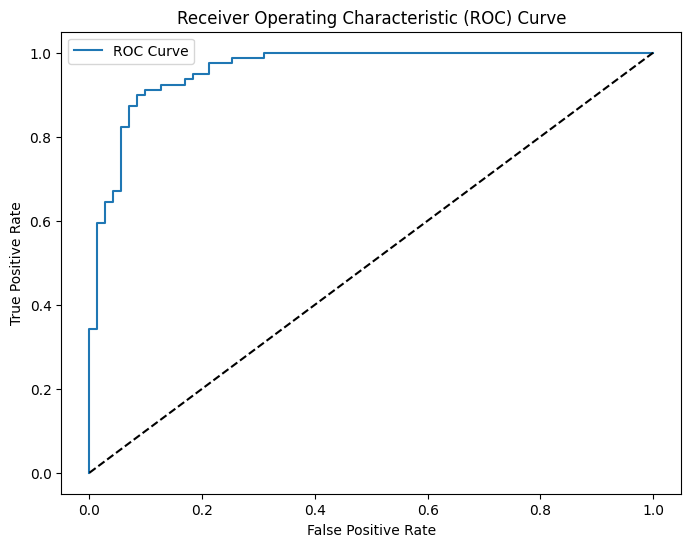

In [116]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test,predictions_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [117]:
# Assess the performance with Cross-validation
kf = StratifiedKFold(n_splits=10)

accuracy_scores = []
roc_auc_scores = []
f1_scores = []
precision_scores = []
recall_scores = []

for train_index, val_index in kf.split(X_train_transformed, y_train_transformed):
    X_train, X_val = X_train_transformed.iloc[train_index], X_train_transformed.iloc[val_index]
    y_train, y_val = y_train_transformed.iloc[train_index], y_train_transformed.iloc[val_index]

    # Fit the model
    glm = sm.GLM(y_train, X_train, family=sm.families.Binomial())
    results = glm.fit()
    
    # Predict
    y_pred_proba = results.predict(X_val)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)



    accuracy_scores.append(accuracy)
    roc_auc_scores.append(roc_auc)
    f1_scores.append(f1)
    precision_scores.append(precision)
    recall_scores.append(recall)

print(f'Average Accuracy: {np.mean(accuracy_scores):.4f}')
print(f'Average ROC AUC: {np.mean(roc_auc_scores):.4f}')
print(f'Average F1 Score: {np.mean(f1_scores):.4f}')
print(f'Average Precision: {np.mean(precision_scores):.4f}')
print(f'Average Recall: {np.mean(recall_scores):.4f}')

Average Accuracy: 0.8371
Average ROC AUC: 0.9159
Average F1 Score: 0.8272
Average Precision: 0.8220
Average Recall: 0.8378


# Experiment on Support Vector Machine (SVM)


In [118]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)

In [119]:
# Load the cleaned dataset
df = pd.read_csv("heart-cleaned.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (746, 12)

First few rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [120]:
# Separate features and target
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

# Identify numerical and categorical columns
numerical_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")
print(f"\nTarget distribution:")
print(y.value_counts())

Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Target distribution:
HeartDisease
0    390
1    356
Name: count, dtype: int64


In [121]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Shape after encoding: {X_encoded.shape}")
print(f"\nFeature names:")
print(X_encoded.columns.tolist())

Shape after encoding: (746, 15)

Feature names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [122]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set size: 596
Test set size: 150

Training target distribution:
HeartDisease
0    312
1    284
Name: count, dtype: int64

Test target distribution:
HeartDisease
0    78
1    72
Name: count, dtype: int64


In [123]:
# Define function for hyperparameter tuning
def tune_clf_hyperparameters(
    pipeline, param_grid, X_train, y_train, cv=5, scoring="accuracy"
):
    grid_search = GridSearchCV(
        pipeline, param_grid, cv=cv, scoring=scoring, n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)

    print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")
    print(f"Best parameters: {grid_search.best_params_}\n")

    return grid_search.best_estimator_, grid_search.best_params_

In [124]:
# Create SVM pipeline with standardization
svm_pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(random_state=42))])

# Configure hyperparameter grid
param_grid_svm = {
    "svm__C": [0.001, 0.005, 0.01, 0.05, 0.1, 1, 10, 20],
    "svm__kernel": ["linear", "rbf", "poly"],
    "svm__gamma": ["scale", "auto", 0.1, 0.5, 1, 5],
    "svm__degree": [2, 3, 4],
}

# Perform GridSearchCV to get all results
grid_search = GridSearchCV(
    svm_pipeline, param_grid_svm, cv=5, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

# Get best model and parameters
best_svm = grid_search.best_estimator_
best_svm_hyperparams = grid_search.best_params_

print("\n" + "=" * 70)
print("SVM Optimal Hyperparameters:")
print("=" * 70)
for param, value in best_svm_hyperparams.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")
print("=" * 70)

# Create DataFrame with all results
results_df = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns and sort by mean test score
results_display = results_df[
    [
        "param_svm__C",
        "param_svm__kernel",
        "param_svm__gamma",
        "param_svm__degree",
        "mean_test_score",
        "std_test_score",
    ]
].copy()

# Sort by mean test score in descending order
results_display = results_display.sort_values("mean_test_score", ascending=False)

# Rename columns for better readability
results_display.columns = [
    "C",
    "Kernel",
    "Gamma",
    "Degree",
    "Mean CV Score",
    "Std CV Score",
]

print("\n" + "=" * 100)
print("ALL HYPERPARAMETER COMBINATIONS RESULTS (Sorted by Mean CV Score)")
print("=" * 100)
print(f"\nTotal combinations tested: {len(results_display)}")
print(f"\nTop 20 combinations:")
print("-" * 100)
print(results_display.head(20).to_string(index=False))
print("\n" + "-" * 100)

# Display all results (can be scrolled in notebook)
print(f"\n\nALL {len(results_display)} COMBINATIONS (Complete Results):")
print("=" * 100)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
print(results_display.to_string(index=False))
pd.reset_option("display.max_rows")
pd.reset_option("display.max_columns")
pd.reset_option("display.width")
pd.reset_option("display.max_colwidth")
print("\n" + "=" * 100)

# Group results by kernel to show summary
print("\n" + "=" * 100)
print("SUMMARY BY KERNEL TYPE")
print("=" * 100)
for kernel in ["linear", "rbf", "poly"]:
    kernel_results = results_display[results_display["Kernel"] == kernel]
    if len(kernel_results) > 0:
        print(f"\n{kernel.upper()} Kernel:")
        print(f"  Best score: {kernel_results['Mean CV Score'].max():.4f}")
        print(f"  Worst score: {kernel_results['Mean CV Score'].min():.4f}")
        print(f"  Average score: {kernel_results['Mean CV Score'].mean():.4f}")
        print(f"  Number of combinations: {len(kernel_results)}")
        best_kernel_combo = kernel_results.iloc[0]
        print(
            f"  Best combination: C={best_kernel_combo['C']}, Gamma={best_kernel_combo['Gamma']}, Degree={best_kernel_combo['Degree']}"
        )

print("\n" + "=" * 100)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

SVM Optimal Hyperparameters:
  svm__C: 0.05
  svm__degree: 2
  svm__gamma: scale
  svm__kernel: rbf

Best cross-validation score: 0.8674

ALL HYPERPARAMETER COMBINATIONS RESULTS (Sorted by Mean CV Score)

Total combinations tested: 432

Top 20 combinations:
----------------------------------------------------------------------------------------------------
    C Kernel Gamma  Degree  Mean CV Score  Std CV Score
0.050    rbf  auto       2       0.867409      0.020383
0.050    rbf scale       3       0.867409      0.020383
0.050    rbf  auto       3       0.867409      0.020383
0.050    rbf scale       4       0.867409      0.020383
0.050    rbf  auto       4       0.867409      0.020383
0.050    rbf scale       2       0.867409      0.020383
0.050    rbf   0.1       2       0.862381      0.024289
0.050    rbf   0.1       3       0.862381      0.024289
0.050    rbf   0.1       4       0.862381      0.024289
0.100    rbf sca

In [125]:
# Use the best model from hyperparameter tuning
svm_model = best_svm

print("Best SVM model (from hyperparameter tuning) is ready!")
print(
    f"Number of support vectors: {len(svm_model.named_steps['svm'].support_vectors_)}"
)
print(f"Support vectors per class: {svm_model.named_steps['svm'].n_support_}")

Best SVM model (from hyperparameter tuning) is ready!
Number of support vectors: 437
Support vectors per class: [221 216]


In [126]:
# Make predictions using the pipeline (it will handle standardization automatically)
y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 50)
print("SVM MODEL PERFORMANCE")
print("=" * 50)
print(f"\nTrain Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n" + "=" * 50)
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Test Set):")
print(
    classification_report(
        y_test, y_test_pred, target_names=["0: No Heart Disease", "1: Heart Disease"]
    )
)

SVM MODEL PERFORMANCE

Train Accuracy: 0.8758 (87.58%)
Test Accuracy: 0.8533 (85.33%)


Confusion Matrix (Test Set):
[[67 11]
 [11 61]]

Classification Report (Test Set):
                     precision    recall  f1-score   support

0: No Heart Disease       0.86      0.86      0.86        78
   1: Heart Disease       0.85      0.85      0.85        72

           accuracy                           0.85       150
          macro avg       0.85      0.85      0.85       150
       weighted avg       0.85      0.85      0.85       150



ROC CURVE ANALYSIS


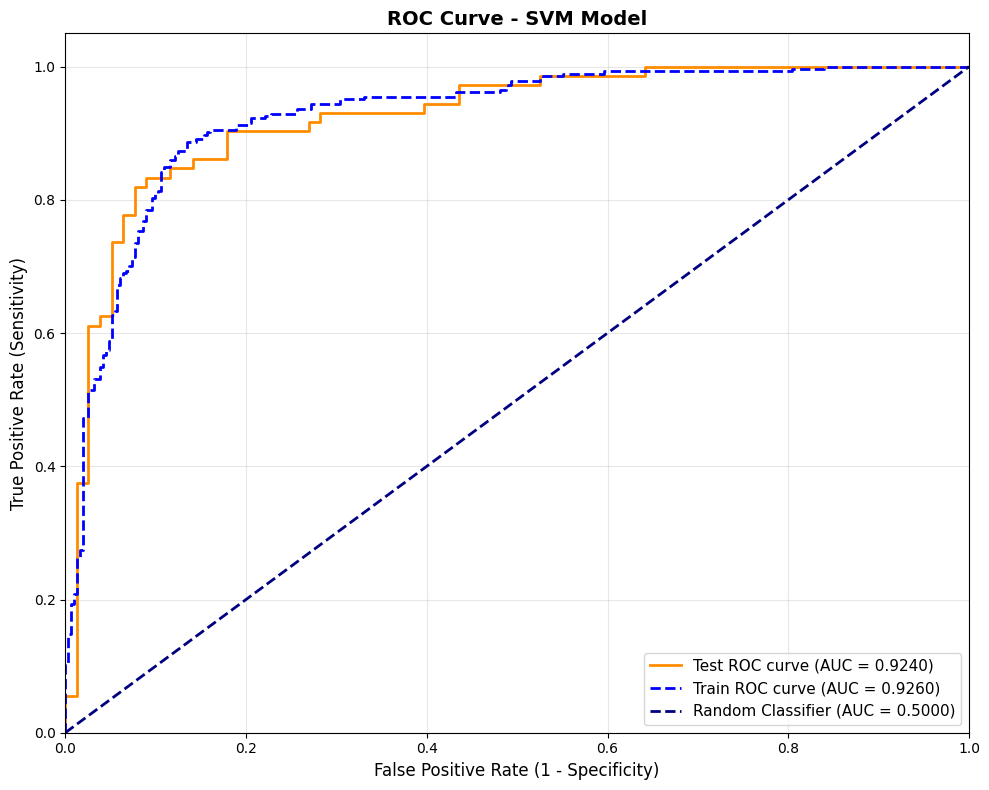


ROC-AUC Score (Test Set): 0.9240
ROC-AUC Score (Train Set): 0.9260

Interpretation:
  - AUC = 0.5: Random classifier (no discriminative ability)
  - AUC = 1.0: Perfect classifier
  - AUC > 0.8: Good classifier
  - AUC > 0.9: Excellent classifier

Our model has an AUC of 0.9240, which indicates excellent performance.


In [127]:
# Plot ROC Curve
print("=" * 70)
print("ROC CURVE ANALYSIS")
print("=" * 70)

# Get decision function scores (SVM doesn't output probabilities by default)
# We need to use decision_function() to get scores for ROC curve
y_train_scores = svm_model.decision_function(X_train)
y_test_scores = svm_model.decision_function(X_test)

# Calculate ROC curve for test set
fpr, tpr, thresholds = roc_curve(y_test, y_test_scores)
roc_auc = roc_auc_score(y_test, y_test_scores)

# Also calculate for training set for comparison
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_scores)
roc_auc_train = roc_auc_score(y_train, y_train_scores)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(
    fpr, tpr, color="darkorange", lw=2, label=f"Test ROC curve (AUC = {roc_auc:.4f})"
)
plt.plot(
    fpr_train,
    tpr_train,
    color="blue",
    lw=2,
    linestyle="--",
    label=f"Train ROC curve (AUC = {roc_auc_train:.4f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--",
    label="Random Classifier (AUC = 0.5000)",
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=12)
plt.title("ROC Curve - SVM Model", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score (Test Set): {roc_auc:.4f}")
print(f"ROC-AUC Score (Train Set): {roc_auc_train:.4f}")
print(f"\nInterpretation:")
print(f"  - AUC = 0.5: Random classifier (no discriminative ability)")
print(f"  - AUC = 1.0: Perfect classifier")
print(f"  - AUC > 0.8: Good classifier")
print(f"  - AUC > 0.9: Excellent classifier")
print(
    f"\nOur model has an AUC of {roc_auc:.4f}, which indicates {'excellent' if roc_auc > 0.9 else 'good' if roc_auc > 0.8 else 'moderate'} performance."
)
print("=" * 70)

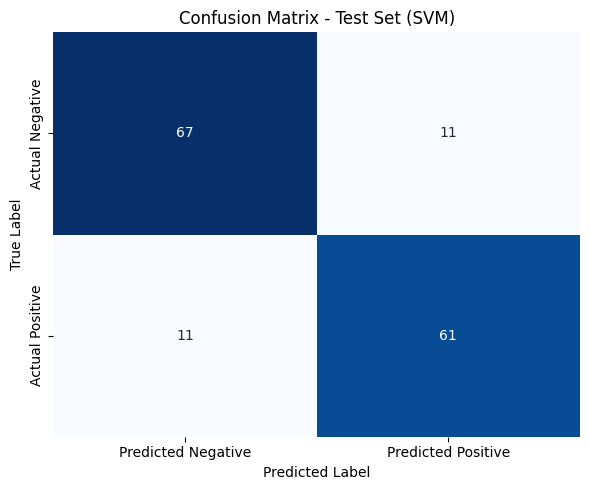

In [128]:
# Plot confusion matrix for test predictions
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"],
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Test Set (SVM)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()